# CIFAR-10: серия контролируемых экспериментов с одной CNN

Цель — понять, какие изменения обучения простой свёрточной сети на CIFAR-10 дают прирост точности на validation, и оформить серию так, чтобы её можно было повторить.

**Протокол.** Один seed (42), фиксированное разбиение train 45 000 / validation 5 000 / test 10 000. Каждый запуск отличается от baseline ровно одним основным фактором. Лучший checkpoint каждого запуска выбирается по validation accuracy. Test используется один раз, в самом конце, для одной выбранной конфигурации.

## 1. Окружение и фиксация seed

In [1]:
import json, random, time, platform, shutil
from dataclasses import dataclass, asdict, replace
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as T
import sklearn
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from torch.utils.data import DataLoader, Subset
from torch.utils.tensorboard import SummaryWriter

SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
OUT = Path(".")
LOGS, CKPT, FIGS = OUT / "runs", OUT / "checkpoints", OUT / "figures"
for p in (LOGS, CKPT, FIGS):
    p.mkdir(exist_ok=True)


def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


env = {
    "python": platform.python_version(),
    "torch": torch.__version__,
    "torchvision": torchvision.__version__,
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "scikit-learn": sklearn.__version__,
    "cuda": torch.version.cuda,
    "device": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu",
}
(OUT / "environment.json").write_text(json.dumps(env, indent=2))
pd.Series(env)

python               3.13.15
torch           2.11.0+cu128
torchvision     0.26.0+cu128
numpy                  2.1.3
pandas                 2.3.3
scikit-learn           1.6.1
cuda                    12.8
device              Tesla T4
dtype: object

## 2. Данные: split и transforms

In [2]:
CLASSES = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]
MEAN, STD = (0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)
norm = [T.ToTensor(), T.Normalize(MEAN, STD)]

AUG = {
    "none": T.Compose(norm),
    "flip_crop": T.Compose([T.RandomHorizontalFlip(), T.RandomCrop(32, padding=4), *norm]),
    "flip_crop_jitter": T.Compose(
        [T.RandomHorizontalFlip(), T.RandomCrop(32, padding=4), T.ColorJitter(0.2, 0.2, 0.2), *norm]
    ),
}
EVAL_TF = AUG["none"]
ROOT = "./data"

full = torchvision.datasets.CIFAR10(ROOT, train=True, download=True)
test_set = torchvision.datasets.CIFAR10(ROOT, train=False, download=True, transform=EVAL_TF)

perm = np.random.RandomState(SEED).permutation(len(full))
VAL_IDX, TRAIN_IDX = perm[:5000], perm[5000:]
np.savez(OUT / "splits.npz", train=TRAIN_IDX, val=VAL_IDX)
print(len(TRAIN_IDX), len(VAL_IDX), len(test_set))


def make_loaders(cfg):
    g = torch.Generator().manual_seed(cfg.seed)
    tr = Subset(torchvision.datasets.CIFAR10(ROOT, train=True, transform=AUG[cfg.augment]), TRAIN_IDX)
    va = Subset(torchvision.datasets.CIFAR10(ROOT, train=True, transform=EVAL_TF), VAL_IDX)
    return (
        DataLoader(tr, cfg.batch_size, shuffle=True, num_workers=2, generator=g),
        DataLoader(va, 512, num_workers=2),
    )

100%|██████████| 170M/170M [00:11<00:00, 15.1MB/s] 


45000 5000 10000


## 3. Модель и конфигурация

In [3]:
def conv_block(cin, cout, bn):
    layers = [nn.Conv2d(cin, cout, 3, padding=1, bias=not bn)]
    if bn:
        layers.append(nn.BatchNorm2d(cout))
    layers.append(nn.ReLU())
    return layers


class SimpleCNN(nn.Module):
    def __init__(self, bn=False, dropout=0.0):
        super().__init__()
        ch = [3, 32, 64, 128]
        layers = []
        for a, b in zip(ch[:-1], ch[1:]):
            layers += conv_block(a, b, bn) + conv_block(b, b, bn) + [nn.MaxPool2d(2)]
        self.features = nn.Sequential(*layers)
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Dropout(dropout), nn.Linear(128 * 4 * 4, 256), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(256, 10),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


@dataclass(frozen=True)
class Config:
    optimizer: str = "sgd"
    lr: float = 0.01
    weight_decay: float = 0.0
    dropout: float = 0.0
    batchnorm: bool = False
    augment: str = "none"
    epochs: int = 15
    batch_size: int = 128
    seed: int = SEED


def make_optimizer(cfg, params):
    if cfg.optimizer == "sgd":
        return torch.optim.SGD(params, lr=cfg.lr, momentum=0.9, weight_decay=cfg.weight_decay)
    if cfg.optimizer == "adam":
        return torch.optim.Adam(params, lr=cfg.lr, weight_decay=cfg.weight_decay)
    return torch.optim.AdamW(params, lr=cfg.lr, weight_decay=cfg.weight_decay)


print(SimpleCNN())
print("params:", sum(p.numel() for p in SimpleCNN().parameters()),
      "| with BatchNorm:", sum(p.numel() for p in SimpleCNN(bn=True).parameters()))

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU()
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU()
    (12): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU()
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.0, inplace=False)
    (2): Linear(in_features=2048, out_feature

## 4. Обучение одного запуска

In [4]:
RESULTS = OUT / "results.json"


def load_results():
    return json.loads(RESULTS.read_text()) if RESULTS.exists() else {}


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    loss = correct = n = 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        out = model(x)
        loss += F.cross_entropy(out, y, reduction="sum").item()
        correct += (out.argmax(1) == y).sum().item()
        n += len(y)
    return loss / n, correct / n


def run(name, factor, cfg):
    results = load_results()
    if name in results:
        return results[name]
    seed_everything(cfg.seed)
    train_dl, val_dl = make_loaders(cfg)
    model = SimpleCNN(cfg.batchnorm, cfg.dropout).to(DEVICE)
    opt = make_optimizer(cfg, model.parameters())
    n_params = sum(p.numel() for p in model.parameters())
    writer = SummaryWriter(LOGS / name)
    writer.add_text("config", "```\n" + json.dumps(asdict(cfg), indent=2) + "\n```")
    writer.add_text("changed_factor", factor)

    hist, best, t0 = [], {"val_acc": -1.0}, time.time()
    for epoch in range(1, cfg.epochs + 1):
        model.train()
        tl = tc = n = 0
        for x, y in train_dl:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            out = model(x)
            loss = F.cross_entropy(out, y)
            loss.backward()
            opt.step()
            tl += loss.item() * len(y)
            tc += (out.argmax(1) == y).sum().item()
            n += len(y)
        vl, va = evaluate(model, val_dl)
        row = dict(epoch=epoch, train_loss=tl / n, train_acc=tc / n, val_loss=vl, val_acc=va)
        hist.append(row)
        writer.add_scalar("loss/train", row["train_loss"], epoch)
        writer.add_scalar("loss/val", vl, epoch)
        writer.add_scalar("acc/train", row["train_acc"], epoch)
        writer.add_scalar("acc/val", va, epoch)
        if va > best["val_acc"]:
            best = row
            torch.save({"model": model.state_dict(), "config": asdict(cfg), "epoch": epoch, "val_acc": va},
                       CKPT / f"{name}.pt")

    writer.add_hparams(
        {k: v for k, v in asdict(cfg).items() if k != "seed"},
        {"hparam/val_acc": best["val_acc"], "hparam/val_loss": best["val_loss"]},
    )
    writer.close()
    res = dict(name=name, factor=factor, **asdict(cfg), params=n_params, best_epoch=best["epoch"],
               train_loss=best["train_loss"], train_acc=best["train_acc"],
               val_loss=best["val_loss"], val_acc=best["val_acc"],
               time_s=round(time.time() - t0), history=hist)
    results = load_results()
    results[name] = res
    RESULTS.write_text(json.dumps(results))
    return res

## 5. Baseline и серия экспериментов

Baseline: SGD с momentum 0.9, learning rate 0.01, без Dropout, BatchNorm, weight decay и аугментаций, 15 эпох, batch size 128.

В каждом запуске меняется один фактор. Для Adam и AdamW learning rate ставится в стандартное для них значение 1e-3 (при lr 0.01 Adam обычно расходится), поэтому в группе «optimizer» вместе с оптимизатором меняется и lr; AdamW без weight decay совпадает с Adam, поэтому у AdamW weight decay равен 0.01.

In [5]:
BASE = Config()
EXPERIMENTS = [
    ("baseline", "—", BASE),
    ("lr_0.003", "learning rate", replace(BASE, lr=0.003)),
    ("lr_0.03", "learning rate", replace(BASE, lr=0.03)),
    ("adam", "optimizer", replace(BASE, optimizer="adam", lr=1e-3)),
    ("adamw", "optimizer", replace(BASE, optimizer="adamw", lr=1e-3, weight_decay=1e-2)),
    ("dropout_0.3", "dropout", replace(BASE, dropout=0.3)),
    ("dropout_0.5", "dropout", replace(BASE, dropout=0.5)),
    ("batchnorm", "batchnorm", replace(BASE, batchnorm=True)),
    ("wd_5e-4", "weight decay", replace(BASE, weight_decay=5e-4)),
    ("wd_5e-3", "weight decay", replace(BASE, weight_decay=5e-3)),
    ("aug_flip_crop", "augmentation", replace(BASE, augment="flip_crop")),
    ("aug_flip_crop_jitter", "augmentation", replace(BASE, augment="flip_crop_jitter")),
]
CFG = {n: c for n, _, c in EXPERIMENTS}

for name, factor, cfg in EXPERIMENTS:
    r = run(name, factor, cfg)
    print(f"{name:22s} val_acc={r['val_acc']:.4f} val_loss={r['val_loss']:.4f} "
          f"best_epoch={r['best_epoch']:2d} time={r['time_s']}s")

baseline               val_acc=0.7724 val_loss=0.7590 best_epoch=11 time=129s
lr_0.003               val_acc=0.6906 val_loss=0.9022 best_epoch=15 time=125s
lr_0.03                val_acc=0.7866 val_loss=0.6509 best_epoch= 7 time=125s
adam                   val_acc=0.7900 val_loss=0.9872 best_epoch=13 time=125s
adamw                  val_acc=0.7860 val_loss=0.7305 best_epoch=10 time=125s
dropout_0.3            val_acc=0.8116 val_loss=0.5722 best_epoch=15 time=125s
dropout_0.5            val_acc=0.7966 val_loss=0.5871 best_epoch=14 time=127s
batchnorm              val_acc=0.8304 val_loss=0.8101 best_epoch=15 time=129s
wd_5e-4                val_acc=0.7716 val_loss=0.7331 best_epoch=11 time=127s
wd_5e-3                val_acc=0.7348 val_loss=0.8057 best_epoch=15 time=128s
aug_flip_crop          val_acc=0.8124 val_loss=0.5397 best_epoch=15 time=171s
aug_flip_crop_jitter   val_acc=0.8084 val_loss=0.5555 best_epoch=15 time=258s


## 6. Комбинированный запуск

Единственный запуск, где меняется несколько факторов сразу. Он собирается автоматически и нужен, чтобы проверить, суммируются ли эффекты полезных изменений, если применить все одновременно. Сначала берётся лучшая по validation конфигурация среди baseline, learning rate и optimizer. Затем к ней добавляется лучший вариант каждой из групп dropout, batchnorm, weight decay, augmentation, если он по отдельности превзошёл эту основу.

In [6]:
df = pd.DataFrame(load_results().values()).drop(columns="history")
core = df[df.factor.isin(["—", "learning rate", "optimizer"])]
core_name = core.loc[core.val_acc.idxmax(), "name"]
core_acc = df.loc[df.name == core_name, "val_acc"].item()
combo, parts = CFG[core_name], [core_name]
for g in ["dropout", "batchnorm", "weight decay", "augmentation"]:
    if g == "weight decay" and combo.optimizer == "adamw":
        continue
    sub = df[df.factor == g]
    b = sub.loc[sub.val_acc.idxmax()]
    if b.val_acc > core_acc:
        diff = {k: v for k, v in asdict(CFG[b["name"]]).items() if v != asdict(BASE)[k]}
        combo = replace(combo, **diff)
        parts.append(b["name"])

CFG["combined"] = combo
r = run("combined", "combination: " + " + ".join(parts), combo)
print(parts)
print(combo)
print(f"val_acc={r['val_acc']:.4f}")

['adam', 'dropout_0.3', 'batchnorm', 'aug_flip_crop']
Config(optimizer='adam', lr=0.001, weight_decay=0.0, dropout=0.3, batchnorm=True, augment='flip_crop', epochs=15, batch_size=128, seed=42)
val_acc=0.8312


## 7. Таблица результатов

In [7]:
results = load_results()
df = pd.DataFrame(results.values())
base_acc = results["baseline"]["val_acc"]
df["delta_val_acc"] = df.val_acc - base_acc
cols = ["name", "factor", "optimizer", "lr", "weight_decay", "dropout", "batchnorm", "augment",
        "params", "best_epoch", "train_loss", "train_acc", "val_loss", "val_acc", "delta_val_acc"]
table = df[cols].round(4)
table.to_csv(OUT / "results.csv", index=False)
table

,name,factor,optimizer,lr,weight_decay,dropout,batchnorm,augment,params,best_epoch,train_loss,train_acc,val_loss,val_acc,delta_val_acc
0,baseline,—,sgd,0.010,0.0000,0.0,False,none,814122,11,0.3153,0.8891,0.7590,0.7724,0.0000
1,lr_0.003,learning rate,sgd,0.003,0.0000,0.0,False,none,814122,15,0.6517,0.7714,0.9022,0.6906,-0.0818
2,lr_0.03,learning rate,sgd,0.030,0.0000,0.0,False,none,814122,7,0.4462,0.8440,0.6509,0.7866,0.0142
3,adam,optimizer,adam,0.001,0.0000,0.0,False,none,814122,13,0.1287,0.9542,0.9872,0.7900,0.0176
4,adamw,optimizer,adamw,0.001,0.0100,0.0,False,none,814122,10,0.2268,0.9195,0.7305,0.7860,0.0136
5,dropout_0.3,dropout,sgd,0.010,0.0000,0.3,False,none,814122,15,0.4230,0.8500,0.5722,0.8116,0.0392
6,dropout_0.5,dropout,sgd,0.010,0.0000,0.5,False,none,814122,14,0.5924,0.7927,0.5871,0.7966,0.0242
7,batchnorm,batchnorm,sgd,0.010,0.0000,0.0,True,none,814570,15,0.0364,0.9882,0.8101,0.8304,0.0580
8,wd_5e-4,weight decay,sgd,0.010,0.0005,0.0,False,none,814122,11,0.3665,0.8711,0.7331,0.7716,-0.0008
9,wd_5e-3,weight decay,sgd,0.010,0.0050,0.0,False,none,814122,15,0.5382,0.8117,0.8057,0.7348,-0.0376


Оценка шума. На 5 000 изображений validation стандартная ошибка измеренной accuracy при accuracy около 0.7 равна sqrt(0.7·0.3/5000) ≈ 0.0065, то есть около 0.65 процентного пункта. Кроме того, каждая конфигурация обучена с одним seed. Разницу в `delta_val_acc` меньше примерно 1 п.п. нельзя считать подтверждённым улучшением.

## 8. Графики

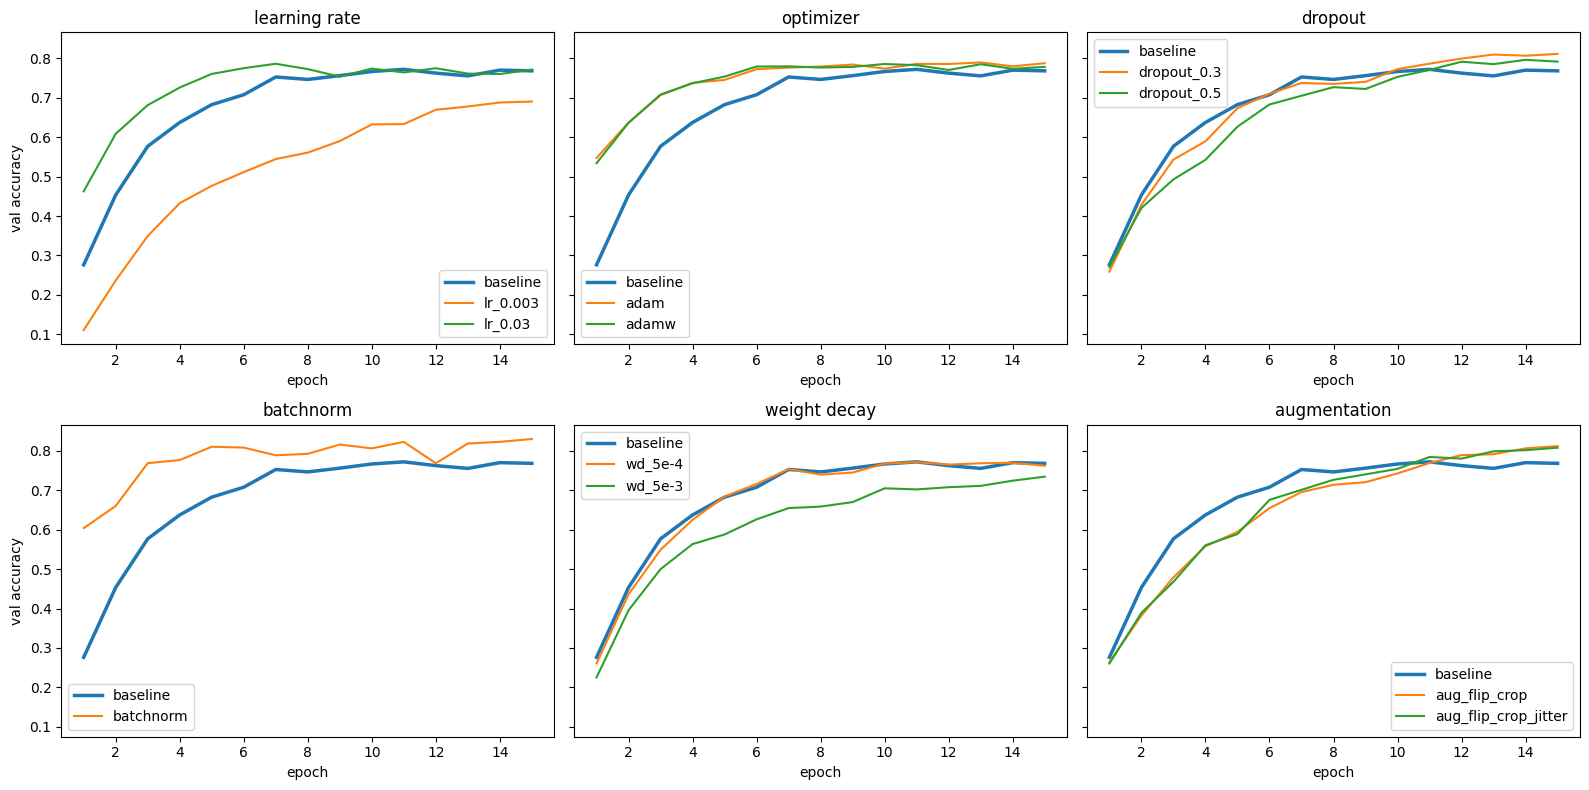

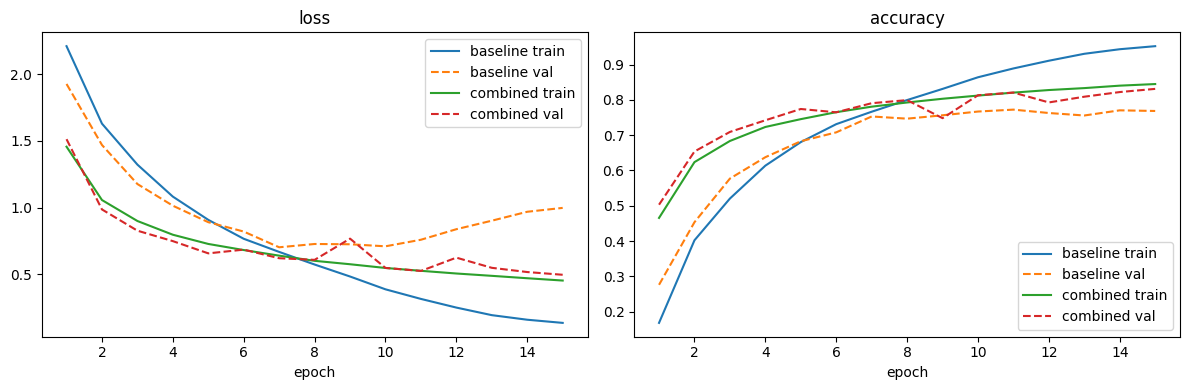

In [8]:
GROUPS = ["learning rate", "optimizer", "dropout", "batchnorm", "weight decay", "augmentation"]
fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharey=True)
for ax, g in zip(axes.ravel(), GROUPS):
    names = ["baseline"] + list(df[df.factor == g].name)
    for n in names:
        h = pd.DataFrame(results[n]["history"])
        ax.plot(h.epoch, h.val_acc, label=n, lw=2.5 if n == "baseline" else 1.5)
    ax.set_title(g)
    ax.set_xlabel("epoch")
    ax.legend()
axes[0, 0].set_ylabel("val accuracy")
axes[1, 0].set_ylabel("val accuracy")
plt.tight_layout()
plt.savefig(FIGS / "val_acc_by_factor.png", dpi=130)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for n in ["baseline", "combined"]:
    h = pd.DataFrame(results[n]["history"])
    axes[0].plot(h.epoch, h.train_loss, label=f"{n} train")
    axes[0].plot(h.epoch, h.val_loss, "--", label=f"{n} val")
    axes[1].plot(h.epoch, h.train_acc, label=f"{n} train")
    axes[1].plot(h.epoch, h.val_acc, "--", label=f"{n} val")
axes[0].set_title("loss")
axes[1].set_title("accuracy")
for a in axes:
    a.set_xlabel("epoch")
    a.legend()
plt.tight_layout()
plt.savefig(FIGS / "baseline_vs_combined.png", dpi=130)
plt.show()

## 9. Финальная модель и единственная оценка на test

Конфигурация выбирается по лучшему значению validation accuracy среди всех запусков. Test считается один раз; повторный запуск ячейки останавливается проверкой на существование `test_metrics.json`.

In [11]:
TEST_FILE = OUT / "test_metrics.json"
assert not TEST_FILE.exists(), "test уже был оценён; повторная оценка запрещена протоколом"

FINAL = df.loc[df.val_acc.idxmax(), "name"]
ckpt = torch.load(CKPT / f"{FINAL}.pt", map_location=DEVICE)
cfg = Config(**ckpt["config"])
model = SimpleCNN(cfg.batchnorm, cfg.dropout).to(DEVICE)
model.load_state_dict(ckpt["model"])
model.eval()

test_dl = DataLoader(test_set, 512, num_workers=2)
probs, labels = [], []
with torch.no_grad():
    for x, y in test_dl:
        probs.append(F.softmax(model(x.to(DEVICE)), 1).cpu())
        labels.append(y)
probs, labels = torch.cat(probs), torch.cat(labels)
preds = probs.argmax(1)
test_loss = F.nll_loss(probs.log(), labels).item()
test_acc = (preds == labels).float().mean().item()

metrics = dict(final_run=FINAL, config=asdict(cfg), checkpoint_epoch=ckpt["epoch"],
               val_acc=ckpt["val_acc"], test_loss=test_loss, test_acc=test_acc)
TEST_FILE.write_text(json.dumps(metrics, indent=2))
metrics

{'final_run': 'combined',
 'config': {'optimizer': 'adam',
  'lr': 0.001,
  'weight_decay': 0.0,
  'dropout': 0.3,
  'batchnorm': True,
  'augment': 'flip_crop',
  'epochs': 15,
  'batch_size': 128,
  'seed': 42},
 'checkpoint_epoch': 15,
 'val_acc': 0.8312,
 'test_loss': 0.5242820978164673,
 'test_acc': 0.82669997215271}

### Confusion Matrix и топ ошибок

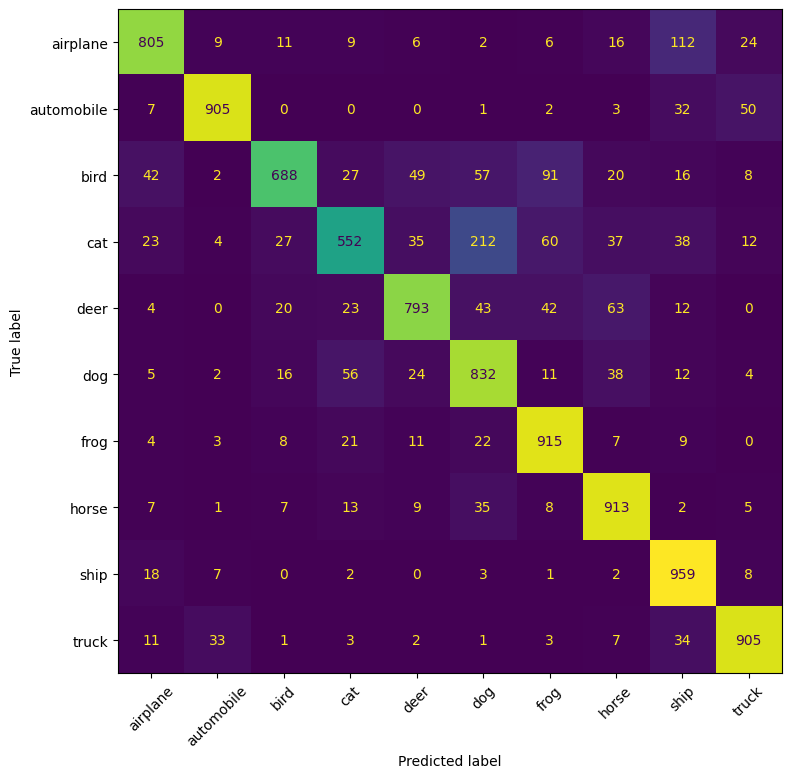

,true,predicted,count
0,cat,dog,212
1,airplane,ship,112
2,bird,frog,91
3,deer,horse,63
4,cat,frog,60
5,bird,dog,57
6,dog,cat,56
7,automobile,truck,50
8,bird,deer,49
9,deer,dog,43


,recall
cat,0.552
bird,0.688
deer,0.793
airplane,0.805
dog,0.832
automobile,0.905
truck,0.905
horse,0.913
frog,0.915
ship,0.959


In [12]:
cm = confusion_matrix(labels, preds)
fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.tight_layout()
plt.savefig(FIGS / "confusion_matrix.png", dpi=130)
plt.show()

pairs = [(CLASSES[i], CLASSES[j], cm[i, j]) for i in range(10) for j in range(10) if i != j]
top = pd.DataFrame(pairs, columns=["true", "predicted", "count"]).sort_values("count", ascending=False)
recall = pd.Series(cm.diagonal() / cm.sum(1), index=CLASSES, name="recall").sort_values()
display(top.head(10).reset_index(drop=True))
display(recall.round(3).to_frame())

### Примеры правильных и ошибочных предсказаний

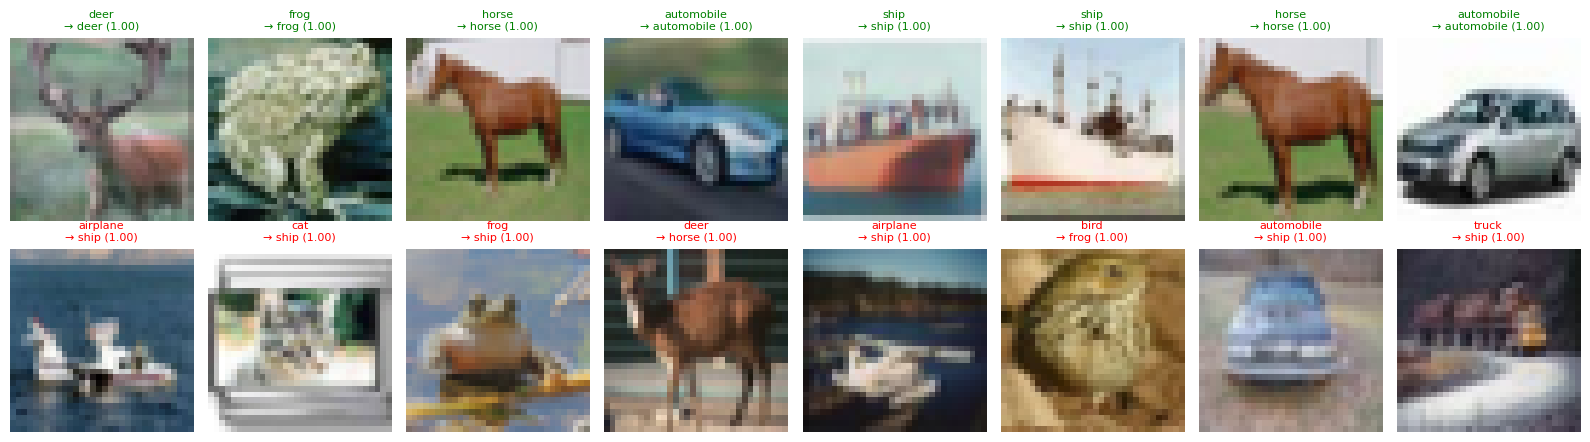

In [13]:
raw = torchvision.datasets.CIFAR10(ROOT, train=False)
conf, _ = probs.max(1)
ok = (preds == labels).nonzero().squeeze(1)
bad = (preds != labels).nonzero().squeeze(1)
ok = ok[conf[ok].argsort(descending=True)][:8]
bad = bad[conf[bad].argsort(descending=True)][:8]

fig, axes = plt.subplots(2, 8, figsize=(16, 4.5))
for row, (idx, title) in enumerate([(ok, "верно"), (bad, "ошибка")]):
    for ax, i in zip(axes[row], idx.tolist()):
        ax.imshow(raw[i][0])
        ax.set_title(f"{CLASSES[labels[i]]}\n→ {CLASSES[preds[i]]} ({conf[i]:.2f})", fontsize=8,
                     color="green" if row == 0 else "red")
        ax.axis("off")
plt.tight_layout()
plt.savefig(FIGS / "examples.png", dpi=130)
plt.show()

## 10. Упаковка результатов

In [14]:
shutil.make_archive("artifacts", "zip", ".", "runs")
print(sorted(p.name for p in OUT.iterdir() if not p.name.startswith(".")))

['artifacts.zip', 'checkpoints', 'data', 'environment.json', 'figures', 'results.csv', 'results.json', 'runs', 'splits.npz', 'test_metrics.json']


## 11. Технический отчёт

### 11.1 Окружение и воспроизведение
Версии библиотек и видеокарта записаны в `environment.json`, конфигурация каждого запуска — в `results.json` и в `runs/` (вкладка Text в TensorBoard). Seed 42 задаёт разбиение данных (`splits.npz`), инициализацию весов и порядок батчей; включены `cudnn.deterministic` и выключен `cudnn.benchmark`. На другой видеокарте или версии PyTorch числа могут разойтись на доли процентного пункта. Запуск: Run All в Kaggle с GPU и включённым интернетом; один запуск занимает около 132 секунд, вся серия из 13 запусков — около 30 минут.

### 11.2 Результаты серии
Validation состоит из 5 000 изображений, поэтому стандартная ошибка accuracy около 0.6 п.п., а каждая конфигурация обучена с одним seed. Изменением, подтверждённым данными, считается разница с baseline больше 1 п.п.; всё меньшее — в пределах шума.

| Фактор | Лучший запуск | val_acc | Δ к baseline (0.7724) | Вывод |
|---|---|---|---|---|
| BatchNorm | batchnorm | 0.8304 | +5.8 п.п. | помог сильнее всего |
| Аугментации | aug_flip_crop | 0.8124 | +4.0 п.п. | помогли; ColorJitter (0.8084) сверх flip + crop ничего не добавил |
| Dropout | dropout_0.3 | 0.8116 | +3.9 п.п. | помог; 0.5 (+2.4 п.п.) хуже, чем 0.3 |
| Optimizer | adam | 0.7900 | +1.8 п.п. | помог слабо; Adam и AdamW (0.7860) неразличимы |
| Learning rate | lr_0.03 | 0.7866 | +1.4 п.п. | помог слабо; lr 0.003 сильно ухудшил (−8.2 п.п.) |
| Weight decay | wd_5e-4 | 0.7716 | −0.1 п.п. | не помог; 5e-3 ухудшил (−3.8 п.п.) |

Почему так, по данным таблицы:
- **BatchNorm.** За 15 эпох train accuracy дошла до 0.988 против 0.889 у baseline: сеть с BatchNorm обучается быстрее. Validation accuracy при этом выше на 5.8 п.п., хотя разрыв между train и validation составляет 16 п.п. Значит, помогла сама скорость и устойчивость обучения, а переобучение на этом запуске не помешало.
- **Аугментации и Dropout** уменьшают разрыв между train и validation. У baseline он 11.7 п.п. (0.889 против 0.772), у aug_flip_crop — минус 0.8 п.п. (0.805 против 0.812), у dropout_0.3 — 3.8 п.п. (0.850 против 0.812). Обе меры помогли, потому что baseline запоминал обучающие картинки.
- **Weight decay 5e-3** ухудшил результат из-за недообучения: train loss вырос с 0.315 до 0.538, train accuracy упала с 0.889 до 0.812. Weight decay 5e-4 слишком слаб, чтобы повлиять.
- **lr 0.003** недообучил модель: лучшая эпоха — последняя, train accuracy 0.771. За 15 эпох с таким шагом сеть не успевает дойти до минимума. Увеличение lr до 0.03 помогло слабо (+1.4 п.п.).
- **Adam** показал train accuracy 0.954 и самый высокий validation loss (0.987) при accuracy 0.790. Это признак переобучения и излишней уверенности модели в ошибках. AdamW с weight decay 0.01 при той же accuracy (0.786) снизил validation loss до 0.731. Разница по accuracy между ними (0.4 п.п.) в пределах шума, разница по loss — нет.

**Комбинированный запуск** (Adam, lr 1e-3, Dropout 0.3, BatchNorm, flip + crop) получил val_acc 0.8312: +5.9 п.п. к baseline и лишь +0.08 п.п. к одному BatchNorm (0.8304). Это в пределах шума: данные не показывают, что факторы сложились. При этом у комбинации самый низкий validation loss среди всех запусков (0.496 против 0.810 у BatchNorm) и малый разрыв между train и validation (0.845 против 0.831). Значит, она лучше откалибрована и меньше переобучена, но на точности это не отразилось. Какая часть комбинации даёт эффект, неизвестно: отдельной проверки без Adam и без Dropout не было.

### 11.3 Итоговое решение
Выбрана конфигурация `combined`: Adam, lr 1e-3, weight decay 0, Dropout 0.3, BatchNorm, аугментации flip + crop, 15 эпох, batch size 128, 814 570 параметров. Выбор сделан по лучшей validation accuracy, как задано протоколом. От batchnorm (0.8304) она отличается на 0.08 п.п., то есть по точности эти конфигурации равноценны; по validation loss `combined` лучше с большим отрывом.

Лучший checkpoint — эпоха 15 (`checkpoints/combined.pt`). Test (оценён один раз): **accuracy 0.8267, loss 0.5243**; validation: accuracy 0.8312, loss 0.4963. Расхождение accuracy между validation и test составляет 0.45 п.п., что в пределах шума. Выбор лучшего из 13 запусков по validation слегка завышает validation-оценку, поэтому честной оценкой качества служит test.

Лучший checkpoint пришёлся на последнюю эпоху: к концу 15 эпох validation accuracy ещё не вышла на плато, обучение остановлено раньше, чем модель перестала улучшаться.

### 11.4 Ошибки модели
Чаще всего модель путает:

| Истинный класс | Предсказанный | Число ошибок |
|---|---|---|
| cat | dog | 212 |
| airplane | ship | 112 |
| bird | frog | 91 |
| deer | horse | 63 |
| cat | frog | 60 |
| bird | dog | 57 |
| dog | cat | 56 |

В тесте по 1 000 изображений на класс, поэтому 212 ошибок «cat → dog» — это 21% всех кошек. Ошибка несимметрична: «dog → cat» встречается в 3.8 раза реже (56). Остальные пары — визуально близкие по цвету фона и силуэту классы (самолёт и корабль на голубом фоне, олень и лошадь, птица и лягушка). Причину асимметрии кошка/собака не проверяли; возможное объяснение — на изображениях 32×32 у кошек и собак мало различимых деталей, и модель чаще выбирает «собака».

### 11.5 Ограничения
- Один seed на конфигурацию: разброс между seed не оценён, различия меньше 1 п.п. не интерпретируются.
- 15 эпох без расписания learning rate: ранжирование факторов при более длинном обучении может измениться, особенно для lr 0.003 и weight decay, которые недообучились.
- Факторы менялись по одному от общего baseline; взаимодействия проверены одним комбинированным запуском, без отдельной проверки вклада каждой части.
- В группе optimizer вместе с оптимизатором менялся learning rate (и weight decay у AdamW).
- Train loss и train accuracy считаются во время эпохи в режиме обучения (с Dropout и аугментациями), поэтому они не сравнимы напрямую с validation.
- Скриншоты TensorBoard не приложены (см. 11.1).

### 11.6 Следующие эксперименты
Бюджет: не более четырёх дополнительных запусков, после чего серия закрывается.
1. **Абляция комбинации.** SGD (lr 0.03) + BatchNorm + flip + crop, без Adam и без Dropout. Гипотеза: результат не хуже 0.83, и тогда Adam и Dropout в комбинации лишние.
2. **Три seed** для `combined` и `batchnorm`. Гипотеза: разница между ними меньше разброса между seed.
3. **40 эпох с cosine-расписанием learning rate** для `combined`. Основание: лучшая эпоха была последней, а train accuracy (0.845) не выше validation. Гипотеза: точность вырастет более чем на 1 п.п.
4. **Ширина свёрток ×2** (64/128/256 каналов) для `combined`. Гипотеза: в сочетании с пунктом 3 снизит число ошибок «cat → dog» ниже 150.